In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
max_features = 10000
maxlen = 500

print("Loading data...")
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)
print(len(x_train), "train sequences")
print(len(x_test), "test sequences")

Loading data...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
25000 train sequences
25000 test sequences


In [3]:
print("Pad sequences (samples x time)")
x_train = sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = sequence.pad_sequences(x_test, maxlen=maxlen)
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

Pad sequences (samples x time)
x_train shape: (25000, 500)
x_test shape: (25000, 500)


In [6]:
embedding_dim = 128
lstm_units = 128

model = Sequential([
    Embedding(max_features, embedding_dim, input_length=maxlen),
    LSTM(lstm_units),
    Dense(1, activation='sigmoid')
])

model.summary()

c:\Users\navee\Desktop\Data_Scientist\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

batch_size = 32
epochs = 3

print("Training model...")
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test))

Training model...
Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 794s 1s/step - accuracy: 0.7945 - loss: 0.4429 - val_accuracy: 0.8473 - val_loss: 0.3670
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 598s 765ms/step - accuracy: 0.8926 - loss: 0.2718 - val_accuracy: 0.8512 - val_loss: 0.3605
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 518s 631ms/step - accuracy: 0.9201 - loss: 0.2104 - val_accuracy: 0.8023 - val_loss: 0.5790


Test Loss: 0.5790
Test Accuracy: 0.8023


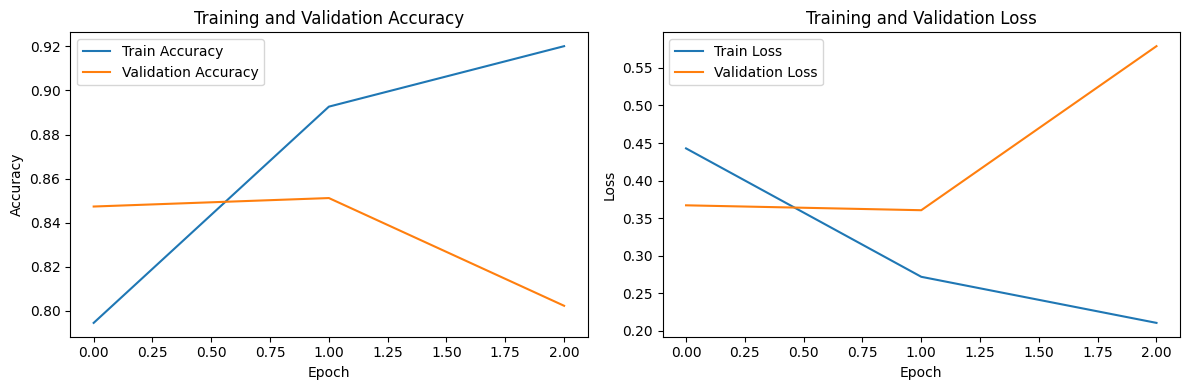

In [8]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
encoded = [word_index.get(word, 2) +3 for word in words_index.get(word, 10000) if word < max_features - 3]
return sequence.pad_sequences([encoded], maxlen=maxlen)

NameError: name 'words_index' is not defined